In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.fft import fft, fftfreq

In [2]:
#Q1 a
'''
The poles and zeros of this system can be found by using the below function:
poles: q = exp(i*2*pi*f_0/f_s), located on the unit circle
zeros: p = (1 + epsilon)q, located outside the unit circle
This function is unstable because the poles are outside of the unit circle when epsilon > 0
This filter is real since the poles and zeros occur in conjugate pairs
'''
def compute_notch_filter_poles_zeros(f0, fs, epsilon):
    q = np.exp(1j * 2 * np.pi * f0 / fs)
    p = (1 + epsilon) * q
    zeros = [q, np.conjugate(q)]
    poles = [p, np.conjugate(p)]
    return poles, zeros

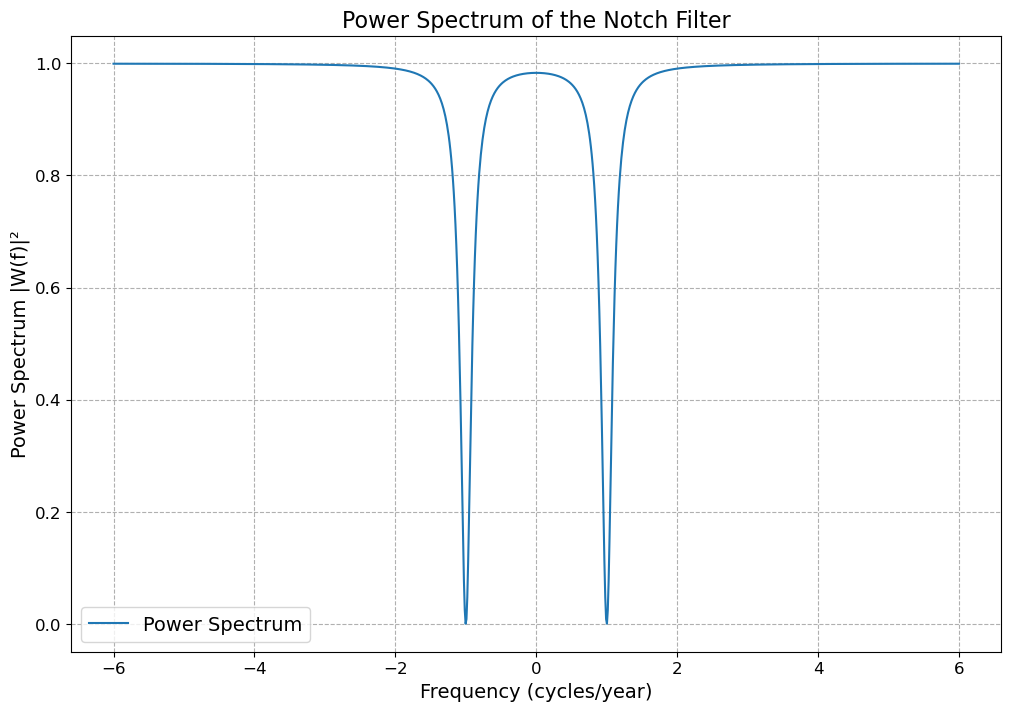

In [3]:
#b
fs = 12
f0 = 1
epsilon = 0.05
M = 1.05

q = np.exp(1j * 2 * np.pi * f0 / fs)
p = (1 + epsilon) * q

f = np.linspace(-fs/2, fs/2, 1000)
omega = 2 * np.pi * f / fs  
W_f = M * ((np.exp(-1j * omega) - q) * (np.exp(-1j * omega) - np.conjugate(q))) / \
      ((np.exp(-1j * omega) - p) * (np.exp(-1j * omega) - np.conjugate(p)))
power_spectrum = np.abs(W_f)**2

plt.figure(figsize=(12,8))
plt.plot(f, power_spectrum,label='Power Spectrum')
plt.xlabel("Frequency (cycles/year)",fontsize=14)
plt.ylabel("Power Spectrum |W(f)|²",fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("Power Spectrum of the Notch Filter",fontsize=16)
plt.grid(True,linestyle="--")
plt.legend(fontsize=14)
plt.show()

In [4]:
#c
'''
Based on the plot, the half level would be 1/2=0.5, and if we were to draw a dashed line, we would expect
a seperation of 0.2 between the intersections, therefore the FWHM would be 0.2 [cycles/year].
To make the notches sharper, we should make the value of epsilon smaller, since then the poles
would move closer to the unit circle.
'''

'\nBased on the plot, the half level would be 1/2=0.5, and if we were to draw a dashed line, we would expect\na seperation of 0.2 between the intersections, therefore the FWHM would be 0.2 [cycles/year].\nTo make the notches sharper, we should make the value of epsilon smaller, since then the poles\nwould move closer to the unit circle.\n'

In [5]:
#d
'''
See proof of values in PDF
a = M
b = -2Mcos(2*pi*f_0/f_s)
c = M
F = -2(1+epsilon)cos(2*pi*f_0/f_s)
G = (1+epsilon)**2
'''

'\nSee proof of values in PDF\na = M\nb = -2Mcos(2*pi*f_0/f_s)\nc = M\nF = -2(1+epsilon)cos(2*pi*f_0/f_s)\nG = (1+epsilon)**2\n'

In [6]:
#e
from scipy.signal import lfilter

def ratFilter(N, D, x):
    N = np.array(N)
    if D[0] != 1:
        N = N / D[0]
        D = D / D[0]
    return lfilter(N, D, x)

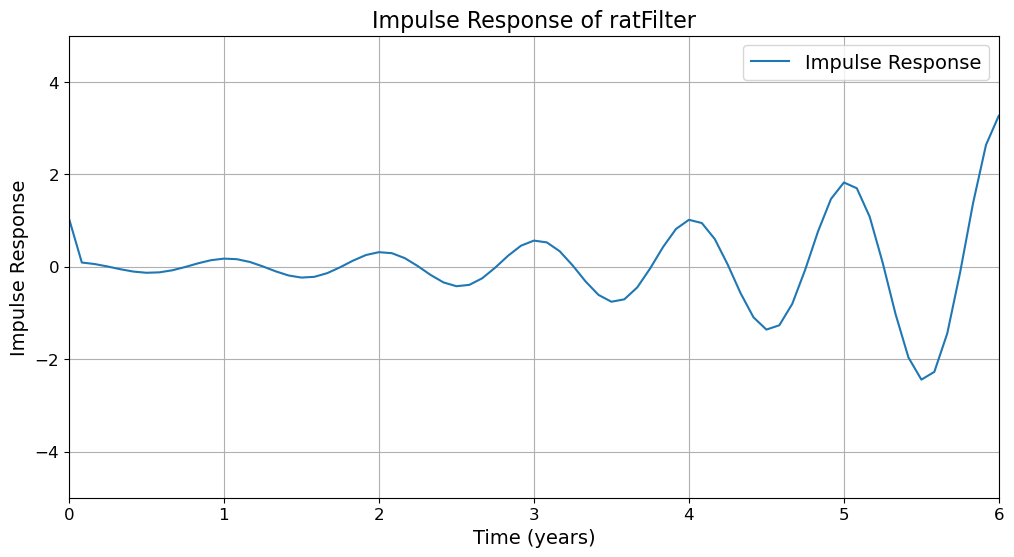

In [7]:
#f
def compute_direct_form_coefficients(f0, fs, epsilon, M):
    a = M
    b = -2 * M * np.cos(2 * np.pi * f0 / fs)
    c = M
    F = -2 * (1 + epsilon) * np.cos(2 * np.pi * f0 / fs)
    G = (1 + epsilon)**2
    return [a, b, c], [1, F, G]

fs = 12.0
tmax = 100
N_samples = int(fs * tmax)
f0 = 1.0
epsilon = 0.05
M = 1.05

t = np.linspace(0, tmax, N_samples, endpoint=False)
impulse = np.zeros(N_samples)
impulse[0] = 1

N_coeff, D_coeff = compute_direct_form_coefficients(f0, fs, epsilon, M)

imp_resp = ratFilter(N_coeff, D_coeff, impulse)

plt.figure(figsize=(12,6))
plt.plot(t, imp_resp,label='Impulse Response')
plt.xlabel("Time (years)",fontsize=14)
plt.ylabel("Impulse Response",fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("Impulse Response of ratFilter",fontsize=16)
plt.xlim(0,6)
plt.ylim(-5,5)
plt.legend(fontsize=14)
plt.grid(True)
plt.show()

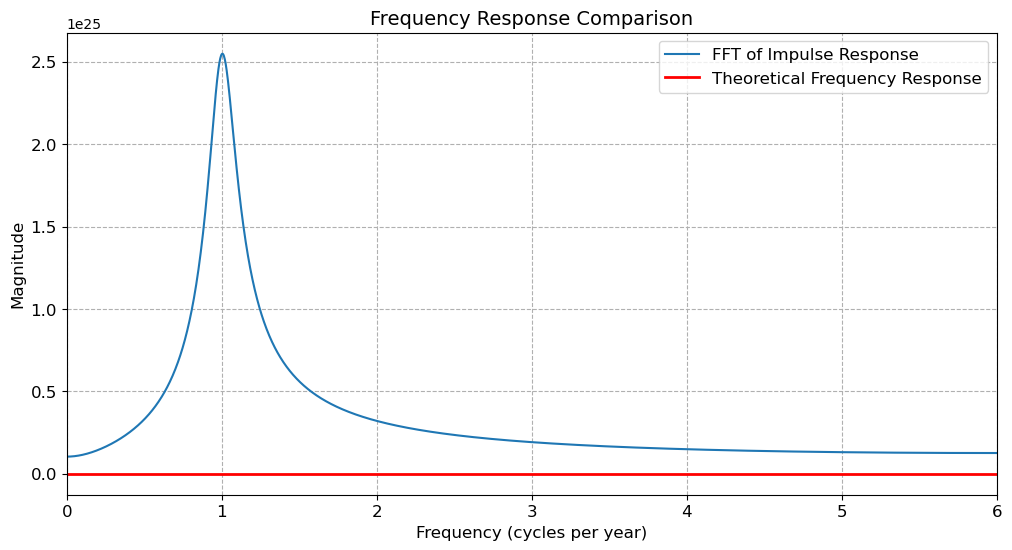

In [8]:
#g
nfft = 4096
H_fft = np.fft.fft(imp_resp, n=nfft)
freqs = np.fft.fftfreq(nfft, d=1/fs)
mask = freqs >= 0
freqs_pos = freqs[mask]
H_fft_pos = H_fft[mask]

f_theo = np.linspace(0, 6, 1000)
z = np.exp(-1j * 2 * np.pi * f_theo / fs)
q = np.exp(1j * 2 * np.pi * f0 / fs)
p = (1 + epsilon) * q
W_theo = M * ((z - q) * (z - np.conjugate(q))) / ((z - p) * (z - np.conjugate(p)))
W_theo_mag = np.abs(W_theo)

plt.figure(figsize=(12, 6))
plt.plot(freqs_pos, np.abs(H_fft_pos), label="FFT of Impulse Response")
plt.plot(f_theo, W_theo_mag, 'r-', linewidth=2, label="Theoretical Frequency Response")
plt.xlim(0, 6)
plt.xlabel("Frequency (cycles per year)",fontsize=12)
plt.ylabel("Magnitude",fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("Frequency Response Comparison",fontsize=14)
plt.grid(True,linestyle='--')
plt.legend(fontsize=12)
plt.show()

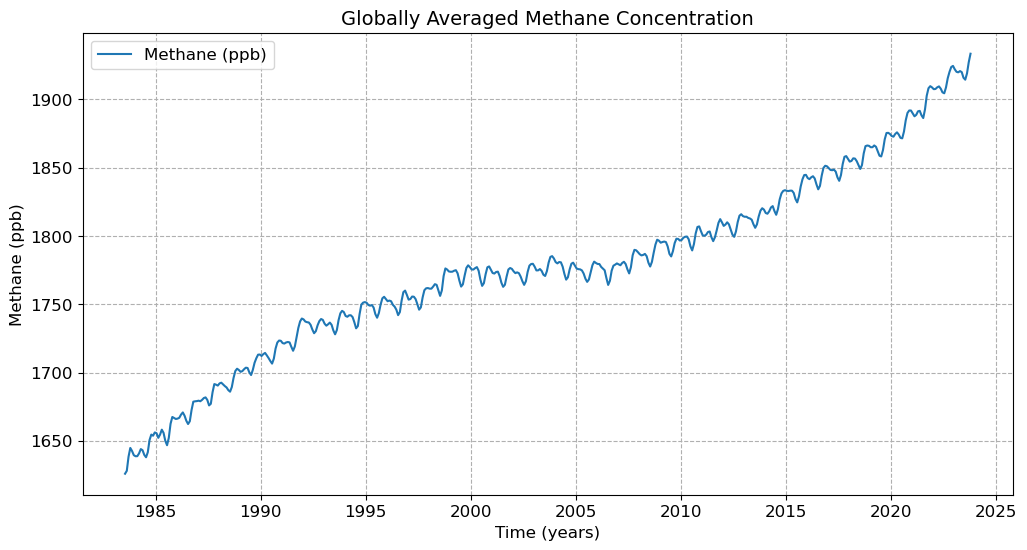

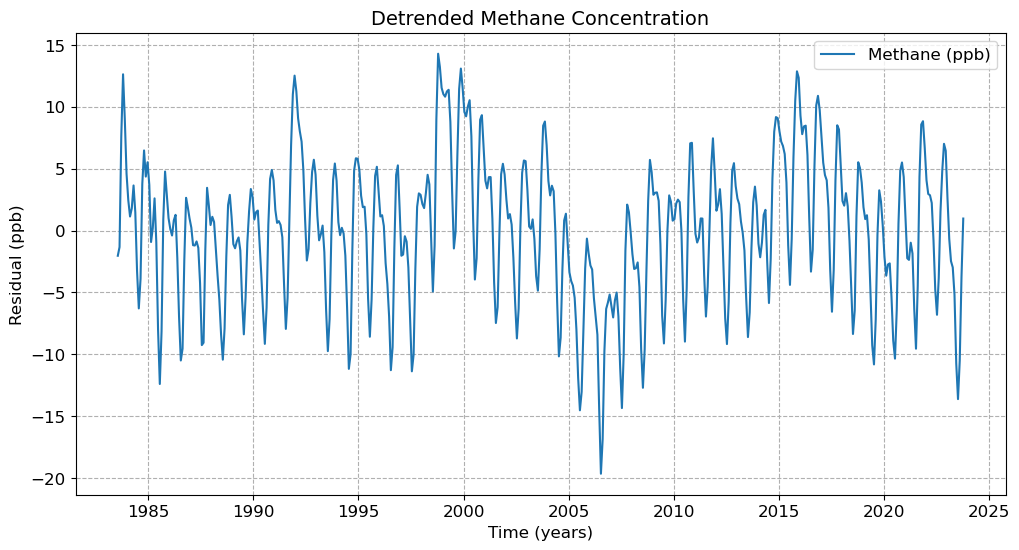

In [9]:
#Q2 a
data = np.loadtxt('methane_global.csv', delimiter=',', skiprows=1)
time = data[:, 2]
methane = data[:, 3]

plt.figure(figsize=(12, 6))
plt.plot(time, methane, label="Methane (ppb)")
plt.xlabel("Time (years)",fontsize=12)
plt.ylabel("Methane (ppb)",fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("Globally Averaged Methane Concentration",fontsize=14)
plt.legend(fontsize=12)
plt.grid(True,linestyle='--')
plt.show()

degree = 3
p = np.polyfit(time, methane, degree)
trend = np.polyval(p, time)
detrended = methane - trend

plt.figure(figsize=(12, 6))
plt.plot(time, detrended, label="Methane (ppb)")
plt.xlabel("Time (years)",fontsize=12)
plt.ylabel("Residual (ppb)",fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("Detrended Methane Concentration",fontsize=14)
plt.legend(fontsize=12)
plt.grid(True,linestyle='--')
plt.show()

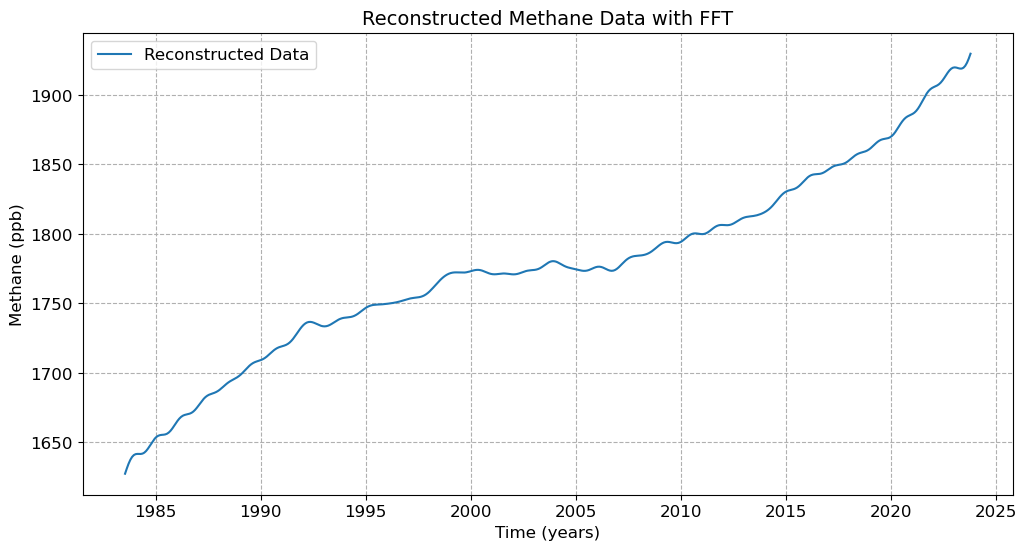

In [10]:
#b
dt = np.mean(np.diff(time))

n = len(detrended)
fft_data = np.fft.fft(detrended)
freqs = np.fft.fftfreq(n, d=dt)
fft_data[np.abs(freqs) > 0.9] = 0
filtered_detrended = np.fft.ifft(fft_data).real

reconstructedfft = filtered_detrended + trend

plt.figure(figsize=(12, 6))
plt.plot(time, reconstructedfft, label="Reconstructed Data")
plt.xlabel("Time (years)",fontsize=12)
plt.ylabel("Methane (ppb)",fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("Reconstructed Methane Data with FFT",fontsize=14)
plt.legend(fontsize=12)
plt.grid(True,linestyle='--')
plt.show()

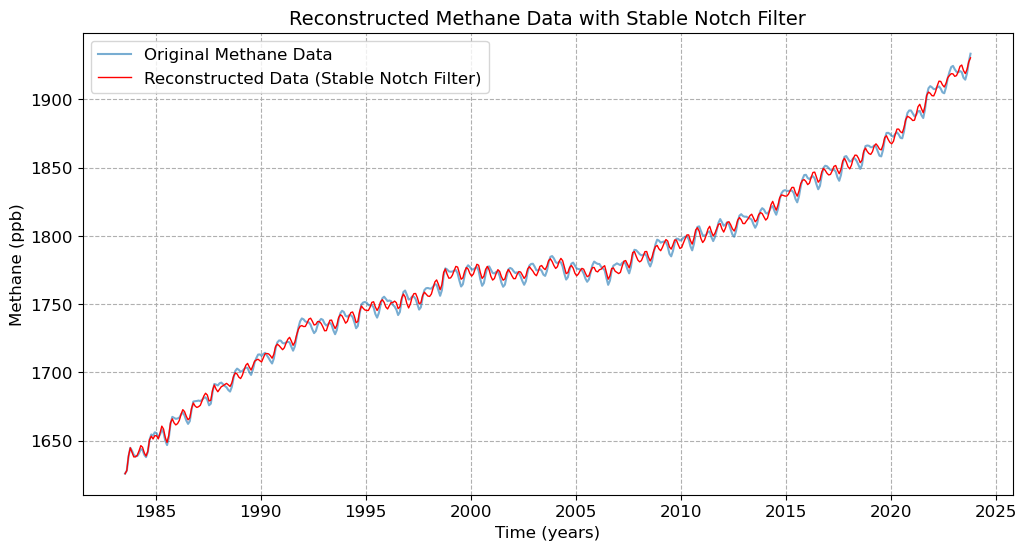

In [11]:
#c
def compute_direct_form_coefficients(f0, fs, epsilon, M):
    a = M
    b = -2 * M * np.cos(2 * np.pi * f0 / fs)
    c = M
    F = -2 * (1 + epsilon) * np.cos(2 * np.pi * f0 / fs)
    G = (1 + epsilon)**2
    return [a, b, c], [1, F, G]

def ratFilter(N, D, x):
    N = np.array(N)
    D = np.array(D)
    if D[0] != 1:
        N = N / D[0]
        D = D / D[0]
    return lfilter(N, D, x)

data = np.loadtxt('methane_global.csv', delimiter=',', skiprows=1)
time = data[:, 2]
methane = data[:, 3]

degree = 3
p = np.polyfit(time, methane, degree)
trend = np.polyval(p, time)
detrended = methane - trend

fs = 12.0
f0 = 1.0
epsilon = -0.05
M = 1.05
N_coeff, D_coeff = compute_direct_form_coefficients(f0, fs, epsilon, M)

filtered_detrended = ratFilter(N_coeff, D_coeff, detrended)

reconstructednot = filtered_detrended + trend

plt.figure(figsize=(12, 6))
plt.plot(time, methane, label="Original Methane Data", alpha=0.6)
plt.plot(time, reconstructednot, label="Reconstructed Data (Stable Notch Filter)", color='red', linewidth=1)
plt.xlabel("Time (years)",fontsize=12)
plt.ylabel("Methane (ppb)",fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("Reconstructed Methane Data with Stable Notch Filter",fontsize=14)
plt.legend(fontsize=12)
plt.grid(True,linestyle='--')
plt.show()

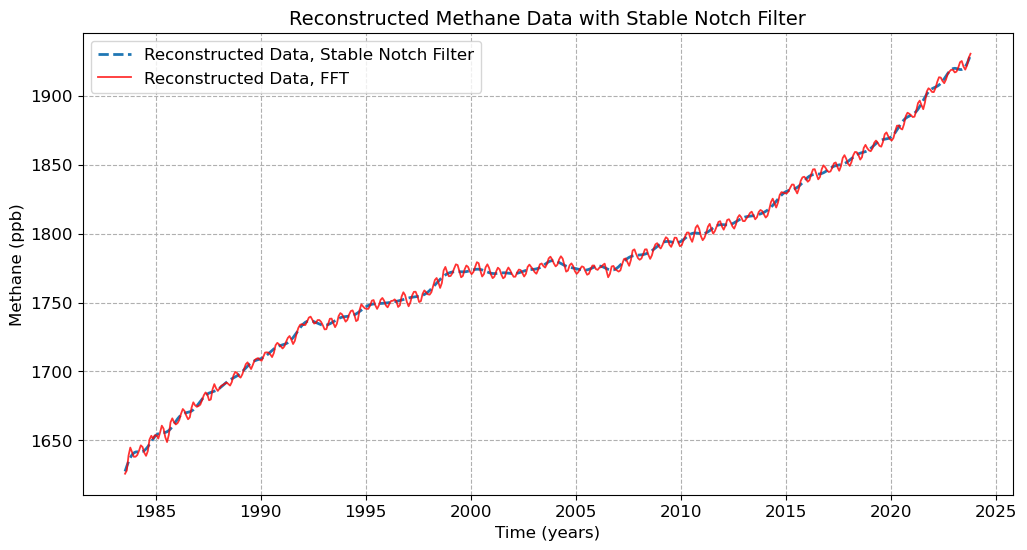

'\nFourier filtering transforms the entire detrended time series to the frequency domain,\nzeroing out the spectral componenets corresponding to frequencies above the annual cycle,\nthen inverse-transform to filter. \nSome advantages would be the ability to explicitly remove\nor attenyate frequency bands, and the great performance with evenly spaced data.\nDisadvantages: Fourier filtering cannont be used for real-time processing, and may introduce edge effects\nat the boundaries due to FFT, it also doesnot work well when the signal is none-staionary, having changes \ngaps can lead to spectral leakages like we looked at before.\n\nDesigning and applying a notch filter in the time domain removes the targeted annual frequency from the\ndetrended signal,then gives us the ability to add back the multi-annual trend in reconstructing the\nfull signal.\nSome advantages of this would be the ability to perate on the time-domain data, which is more sutable\nfor real-time processing. It also has m

In [12]:
#d
plt.figure(figsize=(12, 6))
plt.plot(time, reconstructedfft, label="Reconstructed Data, Stable Notch Filter",linewidth=2,linestyle='--')
plt.plot(time, reconstructednot, label="Reconstructed Data, FFT", color='red', linewidth=1.3,alpha=0.8)
plt.xlabel("Time (years)",fontsize=12)
plt.ylabel("Methane (ppb)",fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("Reconstructed Methane Data with Stable Notch Filter",fontsize=14)
plt.legend(fontsize=12)
plt.grid(True,linestyle='--')
plt.show()
'''
Fourier filtering transforms the entire detrended time series to the frequency domain,
zeroing out the spectral componenets corresponding to frequencies above the annual cycle,
then inverse-transform to filter. 
Some advantages would be the ability to explicitly remove
or attenyate frequency bands, and the great performance with evenly spaced data.
Disadvantages: Fourier filtering cannont be used for real-time processing, and may introduce edge effects
at the boundaries due to FFT, it also doesnot work well when the signal is none-staionary, having changes 
gaps can lead to spectral leakages like we looked at before.

Designing and applying a notch filter in the time domain removes the targeted annual frequency from the
detrended signal,then gives us the ability to add back the multi-annual trend in reconstructing the
full signal.
Some advantages of this would be the ability to perate on the time-domain data, which is more sutable
for real-time processing. It also has more flexibility in causal form and can be adapted for non-stationary
signals (with appropriate design). Most importantly, it can precisely target unwanted frequencies.
Disadvantages: The filter design takes more effort and time compared to the fourier filtering, a stable 
notch filter is important in reconstructing the data. This method also depends sensitively on parameters,
such as epilon and normaliztion factor, making tuning critial throughout the application. The operation in
time domain could also introduce phase shifts and distortions.

To summarize, The Fourier method may have a smoother trend removal but sometimes obscure transient features,
where the notch filter method gives more localized removal at the cost of potential design challenges.

'''

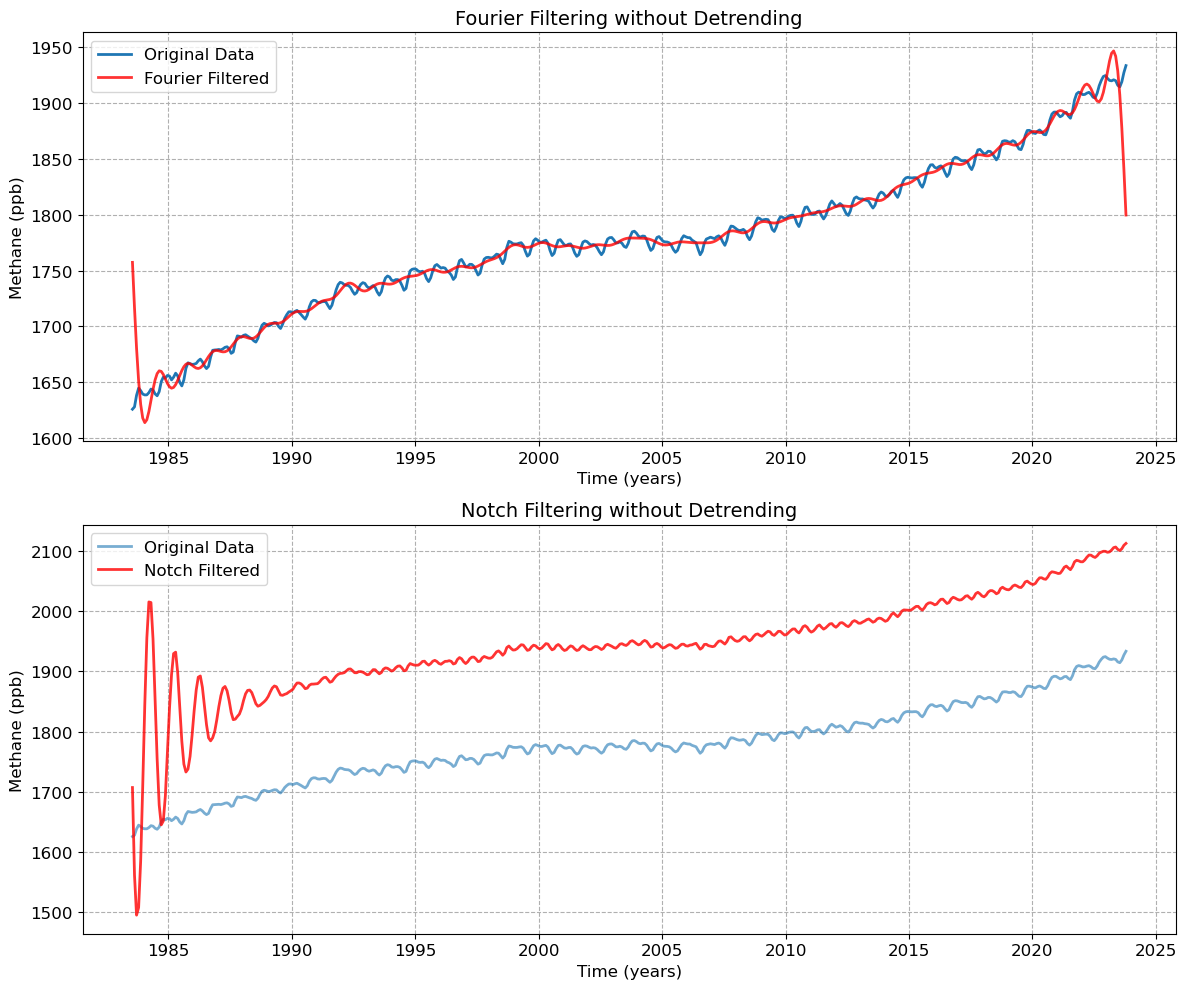

'\nThe detrending has effects of:\nIsolating the oscillations: removing the long-term, low-frequency component(trend), isolating the higher\nfrequency oscillations, leaving room for better filtering operations for both methods. Imporving accuracy\ngreatly.\nReconstruction: when reconstructing without detrending, the distortions will keep existing, \nthus misrepersenting the true behavior.\nHowever, detrending takes an assumed pattern and shape, which sometimes do not fully repersent the data.\n'

In [13]:
data = np.loadtxt('methane_global.csv', delimiter=',', skiprows=1)
time = data[:, 2]
methane = data[:, 3]
dt = np.mean(np.diff(time))
n = len(methane)

fft_data = np.fft.fft(methane)
freqs = np.fft.fftfreq(n, d=dt)
fft_data[np.abs(freqs) > 0.9] = 0
fourier_filtered = np.fft.ifft(fft_data).real

fs = 12.0
f0 = 1.0
epsilon = -0.05
M = 1.05
N_coeff, D_coeff = compute_direct_form_coefficients(f0, fs, epsilon, M)
notch_filtered = ratFilter(N_coeff, D_coeff, methane)

plt.figure(figsize=(12, 10))
plt.subplot(2, 1, 1)
plt.plot(time, methane, label="Original Data", linewidth=2)
plt.plot(time, fourier_filtered, label="Fourier Filtered", color='r', alpha=0.8, linewidth=2)
plt.xlabel("Time (years)",fontsize=12)
plt.ylabel("Methane (ppb)",fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("Fourier Filtering without Detrending",fontsize=14)
plt.legend(fontsize=12)
plt.grid(True,linestyle='--')

plt.subplot(2, 1, 2)
plt.plot(time, methane, label="Original Data", alpha=0.6,linewidth=2)
plt.plot(time, notch_filtered, label="Notch Filtered", color='r', alpha=0.8, linewidth=2)
plt.xlabel("Time (years)",fontsize=12)
plt.ylabel("Methane (ppb)",fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("Notch Filtering without Detrending",fontsize=14)
plt.legend(fontsize=12)
plt.grid(True,linestyle='--')

plt.tight_layout()
plt.show()
'''
The detrending has effects of:
Isolating the oscillations: removing the long-term, low-frequency component(trend), isolating the higher
frequency oscillations, leaving room for better filtering operations for both methods. Imporving accuracy
greatly.
Reconstruction: when reconstructing without detrending, the distortions will keep existing, 
thus misrepersenting the true behavior.
However, detrending takes an assumed pattern and shape, which sometimes do not fully repersent the data.
'''

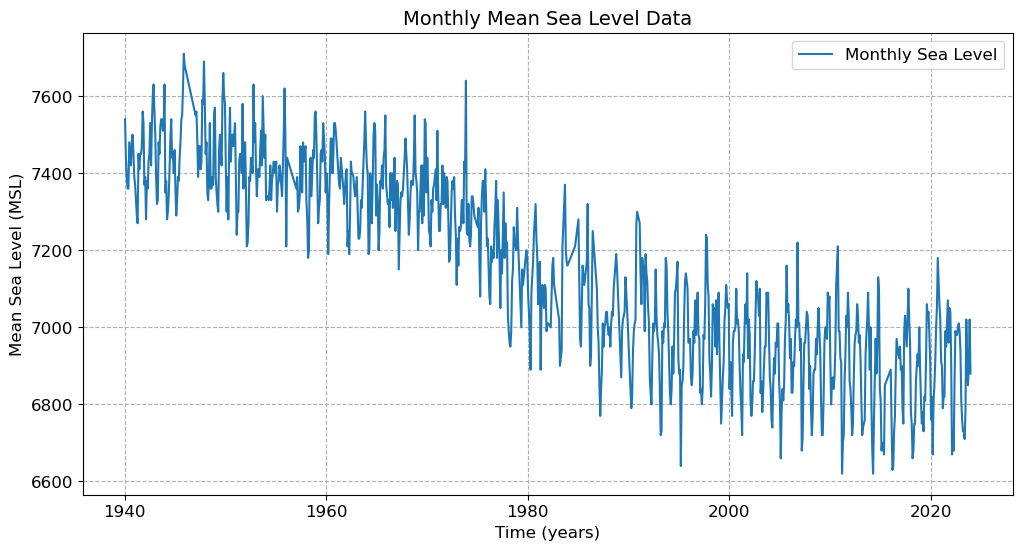

In [14]:
#Q3 a
import numpy as np
import matplotlib.pyplot as plt

filename = 'Churchill_58_46_01.2__94_10_58.8.txt'
data = np.loadtxt(filename, delimiter=';')

time = data[:, 0]
msl = data[:, 1]
valid = msl >= 0
time_valid = time[valid]
msl_valid = msl[valid]

plt.figure(figsize=(12, 6))
plt.plot(time_valid, msl_valid,label='Monthly Sea Level')
plt.xlabel("Time (years)",fontsize=12)
plt.ylabel("Mean Sea Level (MSL)",fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("Monthly Mean Sea Level Data",fontsize=14)
plt.grid(True,linestyle='--')
plt.legend(fontsize=12)
plt.show()

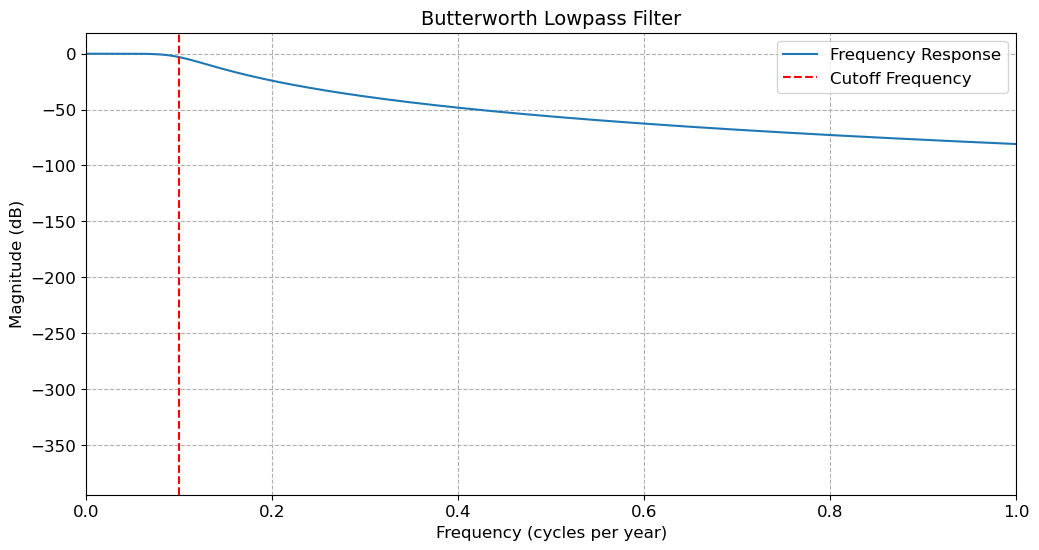

'\nI chose a Butterworth filter because it gives a maximally\nflat response in the passband, meaning that oscillations\nwith periods longer than 10 years are preserved with\nminimal distortion. I picked the 4th order to balance a smooth roll-off.\nThis isolates the decadal variablilty in the mean sea\nlevel data.\n'

In [15]:
#b
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, freqz

fs = 12.0  
cutoff_cpy = 0.1
Wn = cutoff_cpy / (fs/2)
order = 4
b, a = butter(order, Wn, btype='low')
w, h = freqz(b, a, worN=2048)
freqs = (w / (2 * np.pi)) * fs
h_db = 20 * np.log10(np.abs(h))

plt.figure(figsize=(12, 6))
plt.plot(freqs, h_db, label="Frequency Response")
plt.xlabel("Frequency (cycles per year)",fontsize=12)
plt.ylabel("Magnitude (dB)",fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("Butterworth Lowpass Filter",fontsize=14)
plt.grid(True,linestyle='--')
plt.xlim(0, 1)
plt.axvline(x=cutoff_cpy, color='red', linestyle='--', label="Cutoff Frequency")
plt.legend(fontsize=12)
plt.show()
'''
I chose a Butterworth filter because it gives a maximally
flat response in the passband, meaning that oscillations
with periods longer than 10 years are preserved with
minimal distortion. I picked the 4th order to balance a smooth roll-off.
This isolates the decadal variablilty in the mean sea
level data.
'''

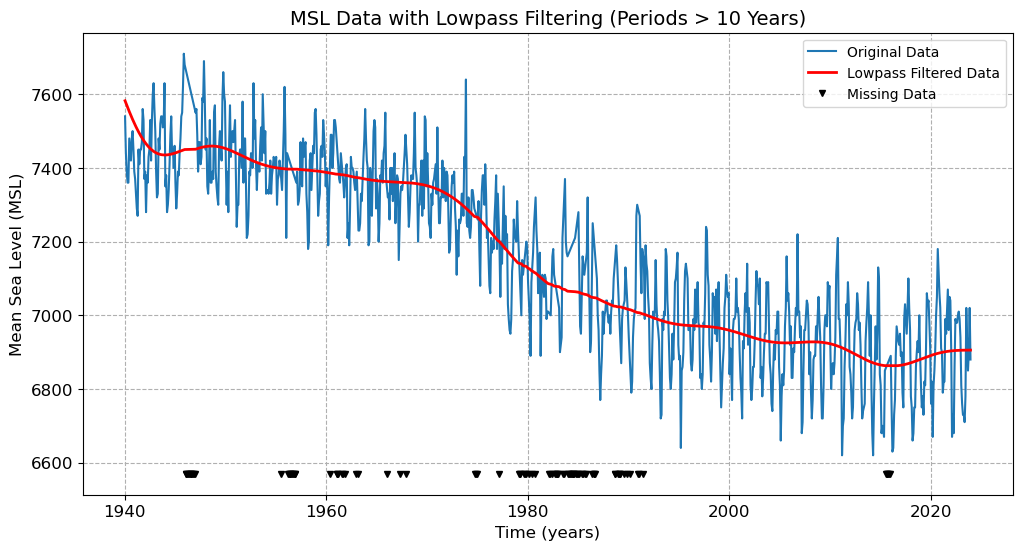

In [16]:
#c
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

filename = 'Churchill_58_46_01.2__94_10_58.8.txt'

data = np.loadtxt(filename, delimiter=';')

time = data[:, 0]
msl = data[:, 1]

valid_mask = msl >= 0
time_valid = time[valid_mask]
msl_valid = msl[valid_mask]

time_missing = time[~valid_mask]

fs = 12.0

cutoff_cpy = 0.1

Wn = cutoff_cpy / (fs/2)
order = 4
b, a = butter(order, Wn, btype='low')

filtered_msl = filtfilt(b, a, msl_valid)

plt.figure(figsize=(12, 6))

plt.plot(time_valid, msl_valid, label="Original Data")

plt.plot(time_valid, filtered_msl, 'r-', linewidth=2, label="Lowpass Filtered Data")

plt.xlabel("Time (years)",fontsize=12)
plt.ylabel("Mean Sea Level (MSL)",fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("MSL Data with Lowpass Filtering (Periods > 10 Years)",fontsize=14)
plt.legend(fontsize=12)
plt.grid(True,linestyle='--')

y_marker = np.min(msl_valid) - 50
plt.plot(time_missing, np.full_like(time_missing, y_marker), 'kv', markersize=5, label="Missing Data")

plt.legend()
plt.show()

Computed sea level rise rate: -8.85 mm/year
Time range: 1940.04 to 2023.96 (Total: 83.92 years)


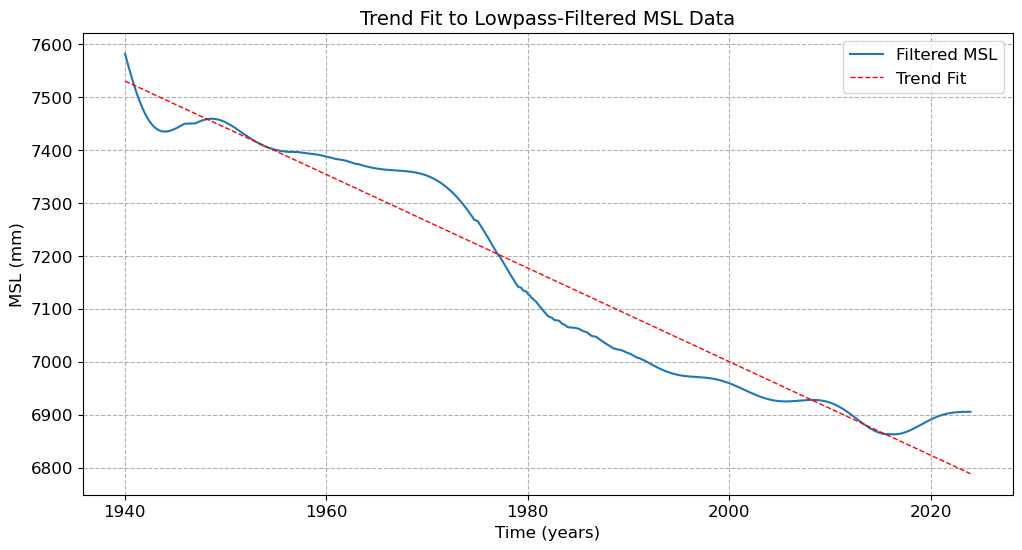

'\nA degree of 1 was used so the fitted coefficients directly shows the rate of\nchange. The lowpass filtering isolates the long-term trend by directly\nattenuating unwanted hih-frequency signals.\n'

In [17]:
#d
p_trend = np.polyfit(time_valid, filtered_msl, 1)
trend_fit = np.polyval(p_trend, time_valid)
slope = p_trend[0]

print("Computed sea level rise rate: {:.2f} mm/year".format(slope))
print("Time range: {:.2f} to {:.2f} (Total: {:.2f} years)".format(
    time_valid[0], time_valid[-1], time_valid[-1] - time_valid[0]))

plt.figure(figsize=(12,6))
plt.plot(time_valid, filtered_msl, label="Filtered MSL")
plt.plot(time_valid, trend_fit, 'r--', linewidth=1, label="Trend Fit")
plt.xlabel("Time (years)",fontsize=12)
plt.ylabel("MSL (mm)",fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("Trend Fit to Lowpass-Filtered MSL Data",fontsize=14)
plt.legend(fontsize=12)
plt.grid(True,linestyle='--')
plt.show()
'''
A degree of 1 was used so the fitted coefficients directly shows the rate of
change. The lowpass filtering isolates the long-term trend by directly
attenuating unwanted hih-frequency signals.
'''